## Problema da ração

In [18]:
%pip install pulp -q

import pulp

prob = pulp.LpProblem("Racao", pulp.LpMaximize)

# Quantidades de racão a ser produzidas
Xamgs = pulp.LpVariable("AMGS", lowBound=0, cat='Continuous')
Xre = pulp.LpVariable("RE", lowBound=0, cat='Continuous')

# Restrições
prob += 1*Xamgs + 4*Xre <= 10000   # carne
prob += 5*Xamgs + 2*Xre <= 30000   # cereal

# Função objetivo: max lucro
prob += 11*Xamgs + 12*Xre

prob.solve(pulp.PULP_CBC_CMD(msg=False))

# Pegando os valores
q1 = Xamgs.varValue
q2 = Xre.varValue
lucro_total = 11*q1 + 12*q2

# Usos dos recursos
uso_carne = 1*q1 + 4*q2
uso_cereal = 5*q1 + 2*q2

print("\nOTIMIZAÇÃO DE PRODUÇÃO DE RAÇÃO:\n")
print(f"Lucro Total Máximo: R$ {lucro_total:.2f}\n")
print("Plano de Produção Ótimo:")
print("Produto\tQuantidade\tLucro Unitário\tLucro Total")
print(f"0\tAMGS\t{q1:.2f}\t\t11\t\t{11*q1:.2f}")
print(f"1\tRE\t{q2:.2f}\t\t12\t\t{12*q2:.2f}")
print("\nUso de Recursos:")
print("Recurso\tUtilizado (kg)\tDisponível (kg)\tPercentual Utilizado")
print(f"0\tCarne\t{uso_carne:.1f}\t\t10000\t\t{uso_carne/10000*100:.2f}%")
print(f"1\tCereal\t{uso_cereal:.1f}\t\t30000\t\t{uso_cereal/30000*100:.2f}%")

Note: you may need to restart the kernel to use updated packages.

OTIMIZAÇÃO DE PRODUÇÃO DE RAÇÃO:

Lucro Total Máximo: R$ 74444.44

Plano de Produção Ótimo:
Produto	Quantidade	Lucro Unitário	Lucro Total
0	AMGS	5555.56		11		61111.11
1	RE	1111.11		12		13333.33

Uso de Recursos:
Recurso	Utilizado (kg)	Disponível (kg)	Percentual Utilizado
0	Carne	10000.0		10000		100.00%
1	Cereal	30000.0		30000		100.00%


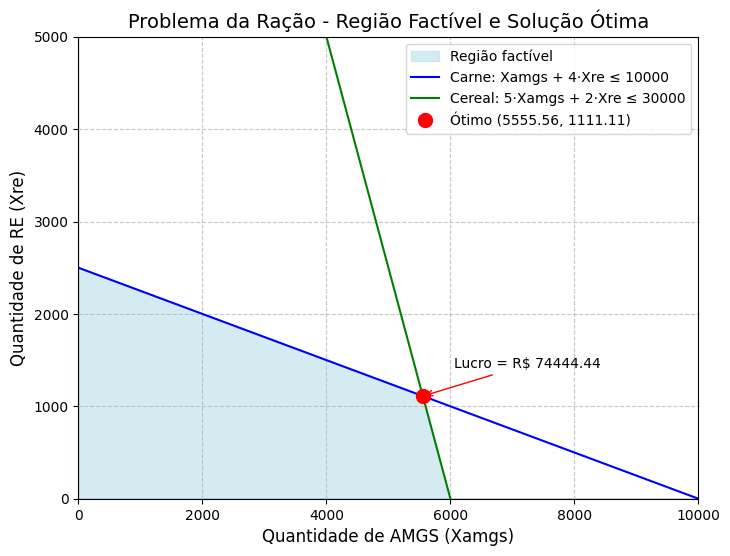

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Dados do problema (mesmas restrições do seu código)
# Carne: 1*Xamgs + 4*Xre <= 10000  -> Xre <= (10000 - Xamgs)/4
# Cereal: 5*Xamgs + 2*Xre <= 30000 -> Xre <= (30000 - 5*Xamgs)/2

Xamgs_vals = np.linspace(0, 12000, 500)

rest_carne = (10000 - Xamgs_vals) / 4
rest_cereal = (30000 - 5*Xamgs_vals) / 2

# Região factível: menor das duas, e não negativa
factivel = np.minimum(rest_carne, rest_cereal)
factivel = np.maximum(factivel, 0)

# Valores ótimos que você encontrou (variáveis contínuas)
q1_otimo = Xamgs.varValue   # já estão definidos no seu código
q2_otimo = Xre.varValue
lucro_otimo = 11*q1_otimo + 12*q2_otimo

# Plotar
plt.figure(figsize=(8,6))
plt.fill_between(Xamgs_vals, 0, factivel, color='lightblue', alpha=0.5, label='Região factível')
plt.plot(Xamgs_vals, rest_carne, 'b-', label='Carne: Xamgs + 4·Xre ≤ 10000')
plt.plot(Xamgs_vals, rest_cereal, 'g-', label='Cereal: 5·Xamgs + 2·Xre ≤ 30000')
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

# Ponto ótimo
plt.plot(q1_otimo, q2_otimo, 'ro', markersize=10, label=f'Ótimo ({q1_otimo:.2f}, {q2_otimo:.2f})')
plt.annotate(f'Lucro = R$ {lucro_otimo:.2f}',
             (q1_otimo, q2_otimo), xytext=(q1_otimo+500, q2_otimo+300),
             arrowprops=dict(arrowstyle='->', color='red'))

plt.xlim(0, 10000)
plt.ylim(0, 5000)
plt.xlabel('Quantidade de AMGS (Xamgs)', fontsize=12)
plt.ylabel('Quantidade de RE (Xre)', fontsize=12)
plt.title('Problema da Ração - Região Factível e Solução Ótima', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()